In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set path to your data folder in Google Drive
# Example: '/content/drive/MyDrive/Spatial_GNN/3.InputML'
DRIVE_PATH = '/content/drive/MyDrive/Spatial GNN/model'
INPUT_DIR = f"{DRIVE_PATH}/3.InputML"
OUTPUT_DIR = f"{DRIVE_PATH}/5.OutputML_GAT_4CLASS"

print(f"Data path: {INPUT_DIR}")
print(f"Output path: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data path: /content/drive/MyDrive/Spatial GNN/model/3.InputML
Output path: /content/drive/MyDrive/Spatial GNN/model/5.OutputML_GAT_4CLASS


In [ ]:
# Install required packages
!pip install -q torch torch-geometric networkx pandas scikit-learn matplotlib seaborn
print("✓ Packages installed successfully!")

✓ Packages installed successfully!


In [ ]:
# Imports
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torch_geometric.loader import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import KFold, LeaveOneOut
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
SEED = 100
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("✓ Imports complete")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✓ Imports complete
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# Plotting functions
def plot_training_validation(train_losses, val_losses, save_path):
    """Plot training and validation loss curves"""
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training vs Validation Loss', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

def plot_validation_accuracy(accuracies, save_path):
    """Plot validation accuracy over epochs"""
    plt.figure(figsize=(10, 6))
    plt.plot(accuracies, linewidth=2, color='green')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Validation Accuracy', fontsize=12)
    plt.title('Validation Accuracy Over Time', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

def plot_lr_schedule(lrs, save_path):
    """Plot learning rate schedule"""
    plt.figure(figsize=(10, 6))
    plt.plot(lrs, linewidth=2, color='orange')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Learning Rate', fontsize=12)
    plt.title('Learning Rate Schedule', fontsize=14)
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

def plot_class_accuracies(y_true, y_pred, label_names, save_path):
    """Plot per-class accuracy histogram"""
    accuracies = []
    for class_id in range(len(label_names)):
        mask = y_true == class_id
        if mask.sum() > 0:
            class_acc = (y_pred[mask] == y_true[mask]).sum() / mask.sum()
            accuracies.append(class_acc)
        else:
            accuracies.append(0.0)

    plt.figure(figsize=(10, 6))
    bars = plt.bar(label_names, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Per-Class Accuracy', fontsize=14)
    plt.ylim(0, 1.0)

    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

print("✓ Plotting functions defined")

✓ Plotting functions defined


## Define Model Components

In [ ]:
# Focal Loss for handling class imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=3.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_weight = (1 - pt) ** self.gamma

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_weight = alpha_t * focal_weight

        loss = focal_weight * ce_loss
        return loss.mean()

print("✓ Focal Loss defined")

✓ Focal Loss defined


In [ ]:
# Data augmentation
def data_augmentation(x, edge_index, training=True):
    if not training:
        return x, edge_index
    if torch.rand(1).item() < 0.2:
        x = x + torch.randn_like(x) * 0.08
    if torch.rand(1).item() < 0.1 and edge_index.shape[1] > 0:
        keep_mask = torch.rand(edge_index.shape[1]) > 0.15
        if keep_mask.sum() > 0:
            edge_index = edge_index[:, keep_mask]
    return x, edge_index

print("✓ Data augmentation defined")

✓ Data augmentation defined


In [ ]:
# Oversampling for minority classes
def oversample_minority_classes(data_list, target_ratio=0.5):
    class_counts = {0: 0, 1: 0, 2: 0, 3: 0}
    for d in data_list:
        for label in d.y:
            class_counts[label.item()] += 1

    max_count = max(class_counts.values())
    target_counts = {i: int(max_count * target_ratio) for i in range(4)}

    oversampled = list(data_list)
    for class_id in [1, 2, 3]:
        if class_counts[class_id] < target_counts[class_id]:
            graphs_with_class = [d for d in data_list if (d.y == class_id).any()]
            if not graphs_with_class:
                continue
            needed = target_counts[class_id] - class_counts[class_id]
            nodes_per_graph = sum((d.y == class_id).sum().item() for d in graphs_with_class) / len(graphs_with_class)
            duplicates_needed = max(1, int(needed / nodes_per_graph))

            for _ in range(duplicates_needed):
                for g in graphs_with_class:
                    oversampled.append(g)

    return oversampled

print("✓ Oversampling function defined")

✓ Oversampling function defined


In [ ]:
# Load GraphML data
def load_graphml_data(graphml_path):
    G = nx.read_graphml(graphml_path)

    node_features = []
    node_labels = []
    node_mapping = {}

    for i, (node_id, data) in enumerate(G.nodes(data=True)):
        node_mapping[node_id] = i
        features = []

        # Geometric features
        x = float(data.get("pos_x", 0.0))
        y = float(data.get("pos_y", 0.0))

        bb_xmin = float(data.get("bb_xmin", 0.0))
        bb_ymin = float(data.get("bb_ymin", 0.0))
        bb_zmin = float(data.get("bb_zmin", 0.0))
        bb_xmax = float(data.get("bb_xmax", 0.0))
        bb_ymax = float(data.get("bb_ymax", 0.0))
        bb_zmax = float(data.get("bb_zmax", 0.0))

        w = bb_xmax - bb_xmin if bb_xmax > bb_xmin else 1.0
        h = bb_ymax - bb_ymin if bb_ymax > bb_ymin else 1.0
        d = bb_zmax - bb_zmin if bb_zmax > bb_zmin else 1.0

        features.extend([x, y, bb_xmin, bb_ymin, bb_zmin, w, h, d])

        volume = w * h * d
        surface_area = 2 * (w * h + h * d + w * d)
        features.extend([volume, surface_area])

        features.extend([
            w / h if h else 0.0,
            h / d if d else 0.0,
            w / d if d else 0.0,
        ])

        length = float(data.get("length", 0.0))
        height = float(data.get("height", 0.0))
        thickness = float(data.get("thickness", 0.0))
        area = float(data.get("area", 0.0))
        width = float(data.get("width", 0.0))
        depth = float(data.get("depth", 0.0))
        features.extend([length, height, thickness, area, width, depth])

        element_type = data.get("element_type", "unknown")
        type_encoding = {"wall": 1, "beam": 2, "foundation": 3, "slab": 4,
                        "genericmodel": 5, "zone": 6, "level": 7, "unknown": 0}
        features.append(type_encoding.get(str(element_type).lower(), 0))

        node_features.append(features)

        label = 0
        if "label_type" in data:
            try:
                label = int(data["label_type"])
                if label not in [0, 1, 2, 3]:
                    label = 0
            except (ValueError, TypeError):
                label = 0

        node_labels.append(label)

    edge_list = []
    for src, dst in G.edges():
        if src in node_mapping and dst in node_mapping:
            edge_list.append([node_mapping[src], node_mapping[dst]])
            edge_list.append([node_mapping[dst], node_mapping[src]])

    if not edge_list:
        return None

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    x_tensor = torch.tensor(node_features, dtype=torch.float)
    y_tensor = torch.tensor(node_labels, dtype=torch.long)

    return Data(x=x_tensor, edge_index=edge_index, y=y_tensor)

print("✓ GraphML loader defined")

✓ GraphML loader defined


In [ ]:
# GAT Model
class ImprovedGATModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_heads=8, num_classes=4, dropout=0.3):
        super().__init__()
        self.gat1 = GATConv(input_dim, hidden_dim // num_heads, heads=num_heads,
                            dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden_dim, hidden_dim // num_heads, heads=num_heads,
                            dropout=dropout, concat=True)
        self.gat3 = GATConv(hidden_dim, hidden_dim // num_heads, heads=num_heads,
                            dropout=dropout, concat=True)
        self.gat4 = GATConv(hidden_dim, hidden_dim // 2, heads=num_heads // 2,
                            dropout=dropout, concat=True)

        self.ln1 = nn.LayerNorm(hidden_dim)
        self.ln2 = nn.LayerNorm(hidden_dim)
        self.ln3 = nn.LayerNorm(hidden_dim)
        self.ln4 = nn.LayerNorm((hidden_dim // 2) * (num_heads // 2))

        final_dim = (hidden_dim // 2) * (num_heads // 2)
        self.classifier = nn.Sequential(
            nn.Linear(final_dim, final_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(final_dim // 2, num_classes),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, batch=None):
        x = self.dropout(self.ln1(F.elu(self.gat1(x, edge_index))))
        x = self.dropout(self.ln2(F.elu(self.gat2(x, edge_index))))
        x = self.dropout(self.ln3(F.elu(self.gat3(x, edge_index))))
        x = self.ln4(F.elu(self.gat4(x, edge_index)))
        return self.classifier(x)

print("✓ GAT Model defined")

✓ GAT Model defined


In [ ]:
# Training and evaluation functions
def train_epoch(model, optimizer, criterion, loader, device):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        x_aug, edge_aug = data_augmentation(data.x, data.edge_index, training=True)
        out = model(x_aug, edge_aug)
        loss = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        pred = out.argmax(dim=1)
        total_correct += (pred == data.y).sum().item()
        total_samples += data.y.size(0)

    return total_loss / len(loader), total_correct / total_samples


def evaluate(model, criterion, loader, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index)
            loss = criterion(out, data.y)
            total_loss += loss.item()
            pred = out.argmax(dim=1)
            total_correct += (pred == data.y).sum().item()
            total_samples += data.y.size(0)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())

    acc = total_correct / total_samples if total_samples else 0.0
    return acc, total_loss / len(loader), all_preds, all_labels

print("✓ Training functions defined")

✓ Training functions defined


In [ ]:
# Check what folders exist
import os
print("Checking Drive structure...")
print(f"Spatial_GNN exists: {os.path.exists('/content/drive/MyDrive/Spatial GNN')}")
print(f"model folder exists: {os.path.exists('/content/drive/MyDrive/Spatial GNN/model')}")
print(f"3.InputML exists: {os.path.exists('/content/drive/MyDrive/Spatial GNN/model/3.InputML')}")

# List what's actually there
if os.path.exists('/content/drive/MyDrive/Spatial GNN/model'):
    print(f"\nContents of model/: {os.listdir('/content/drive/MyDrive/Spatial GNN/model')}")

Checking Drive structure...
Spatial_GNN exists: True
model folder exists: True
3.InputML exists: True

Contents of model/: ['GAT_4class_Colab.ipynb', '5.OutputML_GAT_4CLASS', '3.InputML', 'visualize_graph.py', 'GAT_text2.py', 'batch_combined_inference.py', 'run_inference_from_csv.py', 'combined_inference.py', 'run_ppvc_inference_from_csv.bat', 'map_text_to_elements.py', 'fix_annotation_csv.py', 'inspect_annotation.py', 'GAT_first_model.py', 'csv_to_graphml.py', 'GAT_4class_model.py', '5.OutputML_GAT_DIM 1', '5.OutputML_GAT_TEXT 2 OLD', '5.OutputML_GAT_DIM_OLD', '5.OutputML_GAT_DIM', '.git', '5.OutputML_GAT_NOANNOTATION VS YES', '5.OutputML_GAT_DIM 2', '5.OutputML_GAT', '5.OutputML_GAT_TEXT 1 OLD', '__pycache__', '5.OutputML_GAT_4CLASS 1st try']


## Load Data

In [ ]:
# Copy data to local storage for faster training (avoids slow Google Drive I/O)
import shutil

# Save original Drive paths
DRIVE_INPUT = INPUT_DIR
DRIVE_OUTPUT = OUTPUT_DIR

# Set up local paths
LOCAL_INPUT = '/content/data_local'
LOCAL_OUTPUT = '/content/output_local'

# Copy GraphML files to local storage if not already there
if not os.path.exists(LOCAL_INPUT):
    print(f"Copying data to local storage for faster I/O...")
    shutil.copytree(DRIVE_INPUT, LOCAL_INPUT)
    print(f"✓ Data copied to: {LOCAL_INPUT}")
else:
    print(f"✓ Using existing local data: {LOCAL_INPUT}")

# Update paths to use local storage during training
INPUT_DIR = LOCAL_INPUT
OUTPUT_DIR = LOCAL_OUTPUT
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"\nTraining will use local storage (5-10x faster!)")
print(f"   Input:  {INPUT_DIR}")
print(f"   Output: {OUTPUT_DIR}")
print(f"   Results will be copied back to Drive at the end")

Copying data to local storage for faster I/O...
✓ Data copied to: /content/data_local

Training will use local storage (5-10x faster!)
   Input:  /content/data_local
   Output: /content/output_local
   Results will be copied back to Drive at the end


In [ ]:
# Load GraphML files

graphml_files = sorted(
    [os.path.join(INPUT_DIR, f) for f in os.listdir(INPUT_DIR) if f.endswith(".graphml")]
)

if len(graphml_files) < 2:
    raise ValueError(f"Need at least 2 graphml files. Found {len(graphml_files)} in {INPUT_DIR}")

print(f"Loading {len(graphml_files)} GraphML files from {INPUT_DIR}...")
data_list = []
for fp in graphml_files:
    d = load_graphml_data(fp)
    if d is not None:
        data_list.append(d)

if len(data_list) < 2:
    raise ValueError(f"Parsed fewer than 2 valid graphs. Got {len(data_list)}")

print(f"✓ Loaded {len(data_list)} graphs successfully")

Loading 27 GraphML files from /content/data_local...
✓ Loaded 27 graphs successfully


In [ ]:
# Dataset statistics
total_nodes = sum(len(d.y) for d in data_list)
class_counts = {0: 0, 1: 0, 2: 0, 3: 0}
for d in data_list:
    for label in d.y:
        class_counts[label.item()] += 1

print(f"\nDataset Statistics:")
print(f"  Total nodes: {total_nodes}")
print(f"  Class 0 (No Annotation): {class_counts[0]} ({100*class_counts[0]/total_nodes:.1f}%)")
print(f"  Class 1 (Dimension): {class_counts[1]} ({100*class_counts[1]/total_nodes:.1f}%)")
print(f"  Class 2 (Text): {class_counts[2]} ({100*class_counts[2]/total_nodes:.1f}%)")
print(f"  Class 3 (Both): {class_counts[3]} ({100*class_counts[3]/total_nodes:.1f}%)")

# BALANCED class weights - less extreme than before to prevent bias toward minority classes
class_weights = torch.zeros(4)
for i in range(4):
    if class_counts[i] > 0:
        freq = class_counts[i] / total_nodes
        # Reduced exponent from 1.5 to 1.2 for more balanced weighting
        class_weights[i] = (1.0 / freq) ** 1.2 / 4.0
    else:
        class_weights[i] = 1.0
class_weights = class_weights / class_weights.sum() * 4.0
print(f"\nClass weights: {class_weights.tolist()}")

input_dim = data_list[0].x.shape[1]
output_dim = 4
label_names = ["No Annotation", "Dimension", "Text", "Both"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")


Dataset Statistics:
  Total nodes: 2433
  Class 0 (No Annotation): 1663 (68.4%)
  Class 1 (Dimension): 376 (15.5%)
  Class 2 (Text): 299 (12.3%)
  Class 3 (Both): 95 (3.9%)

Class weights: [0.041382476687431335, 0.3849223256111145, 0.5428102612495422, 3.0308849811553955]

Using device: cuda


## Train Model with Cross-Validation

In [ ]:
# Cross-validation with best checkpoint saving
splitter = KFold(n_splits=5, shuffle=True, random_state=SEED) if len(data_list) >= 5 else LeaveOneOut()
cv_name = "5-fold" if isinstance(splitter, KFold) else "leave-one-out"
print(f"Cross-validation: {cv_name}\n")

fold_accuracies = []
fold_f1_scores = []
all_y_true, all_y_pred = [], []
best_fold_f1, best_state = -1, None

for fold, (train_idx, test_idx) in enumerate(splitter.split(data_list), start=1):
    print(f"\n{'='*60}")
    print(f"  Fold {fold}/{splitter.get_n_splits(data_list)}")
    print(f"{'='*60}")
    fold_dir = os.path.join(OUTPUT_DIR, f"fold_{fold}")
    os.makedirs(fold_dir, exist_ok=True)

    train_data = [data_list[i] for i in train_idx]
    test_data = [data_list[i] for i in test_idx]

    # INCREASED oversampling slightly to help minority classes reach 60%+
    train_data_oversampled = oversample_minority_classes(train_data, target_ratio=0.35)
    print(f"  Training: {len(train_data)} graphs -> {len(train_data_oversampled)} after oversampling")

    # Smaller batch size for better gradient diversity
    train_loader = DataLoader(train_data_oversampled, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

    model = ImprovedGATModel(
        input_dim=input_dim, hidden_dim=128, num_heads=8,
        num_classes=output_dim, dropout=0.4
    ).to(device)

    # REDUCED gamma further for more balanced learning
    criterion = FocalLoss(alpha=class_weights.to(device), gamma=1.2)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=0.03)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.7, patience=25)

    best_val_f1, best_val_acc, best_epoch, patience_ctr, patience = 0.0, 0.0, 0, 0, 80
    best_min_class_recall = 0.0  # NEW: Track minimum class recall
    epochs = 300
    train_losses, test_losses, test_accuracies, test_f1s, lrs = [], [], [], [], []

    # Save best model state for this fold
    best_fold_state = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, optimizer, criterion, train_loader, device)
        te_acc, te_loss, te_preds, te_labels = evaluate(model, criterion, test_loader, device)

        # Calculate per-class metrics
        if len(set(te_labels)) > 1:
            prec, rec, f1, _ = precision_recall_fscore_support(
                te_labels, te_preds, labels=range(4), average='macro', zero_division=0
            )
            # Get per-class recall to ensure ALL classes are learning
            _, per_class_recall, _, _ = precision_recall_fscore_support(
                te_labels, te_preds, labels=range(4), average=None, zero_division=0
            )
            min_class_recall = per_class_recall.min()  # Worst performing class
        else:
            prec = rec = f1 = 0.0
            min_class_recall = 0.0

        train_losses.append(tr_loss)
        test_losses.append(te_loss)
        test_accuracies.append(te_acc)
        test_f1s.append(f1)
        lrs.append(optimizer.param_groups[0]["lr"])

        scheduler.step(f1)

        if epoch % 10 == 0 or epoch <= 10:
            print(
                f"Epoch {epoch:03d} | "
                f"TrainLoss={tr_loss:.4f} TrainAcc={tr_acc:.4f} | "
                f"TestLoss={te_loss:.4f} TestAcc={te_acc:.4f} | "
                f"F1={f1:.3f} MinRecall={min_class_recall:.3f} | LR={lrs[-1]:.6f}"
            )

        # NEW: Save best model based on BALANCED metric (combination of F1 and min class recall)
        # This ensures no single class is left behind
        balanced_score = f1 * 0.6 + min_class_recall * 0.4  # Weight both overall and worst-case performance
        
        if balanced_score > (best_val_f1 * 0.6 + best_min_class_recall * 0.4):
            best_val_f1 = f1
            best_min_class_recall = min_class_recall
            best_val_acc = te_acc
            best_epoch = epoch
            best_fold_state = model.state_dict().copy()
            patience_ctr = 0
            print(f"    ✓ New best balanced score: F1={f1:.4f}, MinRecall={min_class_recall:.4f}")
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch} (best was epoch {best_epoch})")
            break

        # Plot progress every 25 epochs
        if epoch % 25 == 0:
            plot_training_validation(train_losses, test_losses,
                                   os.path.join(fold_dir, "training_validation.png"))
            plot_validation_accuracy(test_accuracies,
                                   os.path.join(fold_dir, "validation_accuracy.png"))
            plot_lr_schedule(lrs, os.path.join(fold_dir, "lr_schedule.png"))

    # Load best checkpoint from this fold
    if best_fold_state is not None:
        model.load_state_dict(best_fold_state)
        print(f"Loaded best checkpoint from epoch {best_epoch}")

    # Final evaluation with best checkpoint
    te_acc_final, te_loss_final, y_pred_fold, y_true_fold = evaluate(
        model, criterion, test_loader, device
    )

    # Calculate final F1 and per-class metrics
    if len(set(y_true_fold)) > 1:
        final_prec, final_rec, final_f1, _ = precision_recall_fscore_support(
            y_true_fold, y_pred_fold, labels=range(4), average='macro', zero_division=0
        )
        # Calculate per-class accuracies AND recalls
        per_class_acc = []
        per_class_recall = []
        for class_id in range(4):
            mask = np.array(y_true_fold) == class_id
            if mask.sum() > 0:
                class_acc = (np.array(y_pred_fold)[mask] == np.array(y_true_fold)[mask]).sum() / mask.sum()
                per_class_acc.append(class_acc)
                per_class_recall.append(class_acc)  # For classification, accuracy = recall per class
            else:
                per_class_acc.append(0.0)
                per_class_recall.append(0.0)
    else:
        final_f1 = 0.0
        per_class_acc = [0.0] * 4
        per_class_recall = [0.0] * 4

    fold_accuracies.append(te_acc_final)
    fold_f1_scores.append(final_f1)
    all_y_true.extend(y_true_fold)
    all_y_pred.extend(y_pred_fold)

    # Save confusion matrix
    cm = confusion_matrix(y_true_fold, y_pred_fold, labels=range(output_dim))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"Fold {fold} Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(os.path.join(fold_dir, "confusion_matrix.png"))
    plt.show()

    # Plot per-class accuracies for this fold
    plot_class_accuracies(
        np.array(y_true_fold), np.array(y_pred_fold), label_names,
        os.path.join(fold_dir, "class_accuracies_histogram.png")
    )

    # Save best model based on F1 score
    if final_f1 > best_fold_f1:
        best_fold_f1 = final_f1
        best_state = best_fold_state
        print(f"    🏆 New best overall model! (F1: {final_f1:.4f})")

    print(f"\nFold {fold} Best Results (from epoch {best_epoch}):")
    print(f"  Overall Accuracy: {te_acc_final:.4f}")
    print(f"  Overall F1 Score: {final_f1:.4f}")
    print(f"  Per-class Recall (should all be ≥60%):")
    for i, (name, recall) in enumerate(zip(label_names, per_class_recall)):
        status = "✓" if recall >= 0.60 else "✗"
        print(f"    {status} {name}: {recall:.4f}")

print("\n" + "="*60)
print("Training Complete!")
print(f"Best F1 across all folds: {best_fold_f1:.4f}")
print("="*60)

Output hidden; open in https://colab.research.google.com to view.

## Results and Model Saving

In [87]:
# Cross-validation summary
fold_accuracies = np.array(fold_accuracies)
fold_f1_scores = np.array(fold_f1_scores)

print(f"\nFold Results:")
for i, (acc, f1) in enumerate(zip(fold_accuracies, fold_f1_scores), start=1):
    print(f"  Fold {i}: Accuracy={acc:.4f}, F1={f1:.4f}")

print(f"\nMean Accuracy: {fold_accuracies.mean():.4f} ± {fold_accuracies.std():.4f}")
print(f"Mean F1 Score: {fold_f1_scores.mean():.4f} ± {fold_f1_scores.std():.4f}")
print(f"\nBest F1 Score: {best_fold_f1:.4f}")


Fold Results:
  Fold 1: Accuracy=0.3675, F1=0.4089
  Fold 2: Accuracy=0.6097, F1=0.5725
  Fold 3: Accuracy=0.2105, F1=0.2827
  Fold 4: Accuracy=0.3208, F1=0.3131
  Fold 5: Accuracy=0.4982, F1=0.4075

Mean Accuracy: 0.4013 ± 0.1392
Mean F1 Score: 0.3969 ± 0.1011

Best F1 Score: 0.5725


In [88]:
# Save best model
best_model = ImprovedGATModel(
    input_dim=input_dim, hidden_dim=128, num_heads=8,
    num_classes=output_dim, dropout=0.3
).to(device)
best_model.load_state_dict(best_state)

pth_path = os.path.join(OUTPUT_DIR, "trained_model.pth")
torch.save({
    "model_state_dict": best_model.state_dict(),
    "input_dim": input_dim,
    "output_dim": output_dim,
    "best_fold_acc": best_fold_acc,
    "cv_mean_acc": fold_accuracies.mean(),
    "cv_std_acc": fold_accuracies.std(),
    "label_names": label_names,
    "class_counts": class_counts,
}, pth_path)

print(f"\n✓ Model saved to: {pth_path}")


✓ Model saved to: /content/output_local/trained_model.pth


In [89]:
# Overall metrics
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

precision, recall, f1, support = precision_recall_fscore_support(
    all_y_true, all_y_pred, labels=range(output_dim), zero_division=0
)

metrics_df = pd.DataFrame({
    "Class": label_names,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support
})

metrics_csv = os.path.join(OUTPUT_DIR, "per_class_metrics.csv")
metrics_df.to_csv(metrics_csv, index=False)
print(f"\n✓ Metrics saved to: {metrics_csv}")
print(f"\n{metrics_df.to_string(index=False)}")


✓ Metrics saved to: /content/output_local/per_class_metrics.csv

        Class  Precision   Recall  F1-Score  Support
No Annotation   0.861818 0.285027  0.428378     1663
    Dimension   0.513841 0.789894  0.622642      376
         Text   0.178791 0.682274  0.283333      299
         Both   0.268293 0.463158  0.339768       95


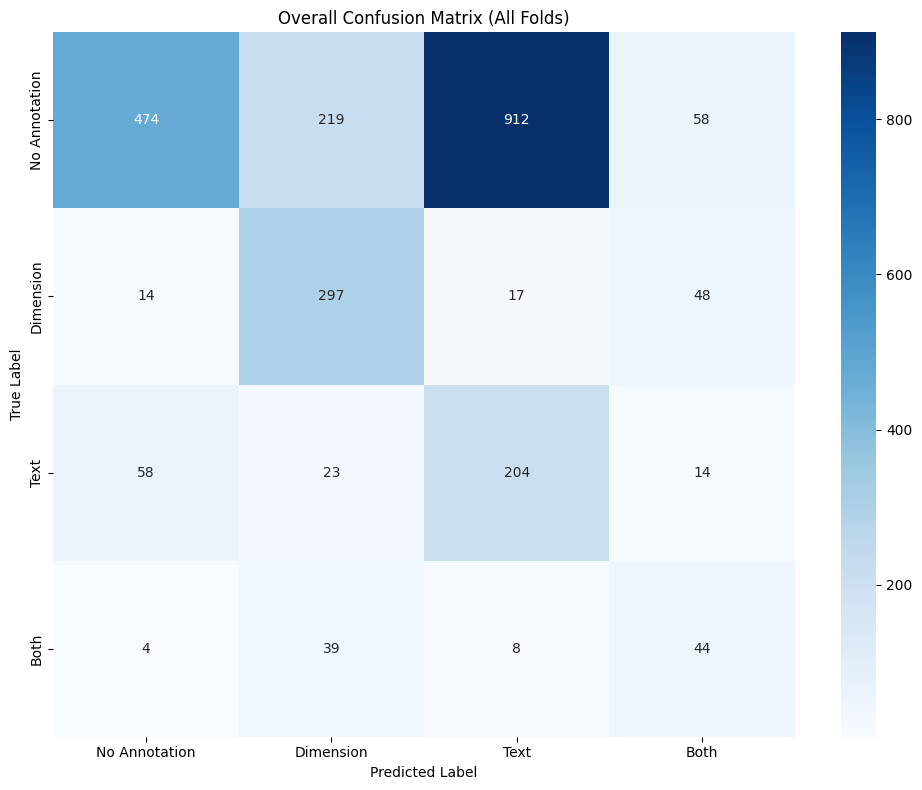


✓ All results saved to: /content/output_local/


In [90]:
# Overall confusion matrix
cm = confusion_matrix(all_y_true, all_y_pred, labels=range(output_dim))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.title("Overall Confusion Matrix (All Folds)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_overall.png"))
plt.show()

print(f"\n✓ All results saved to: {OUTPUT_DIR}/")


📊 Generating overall class accuracies...


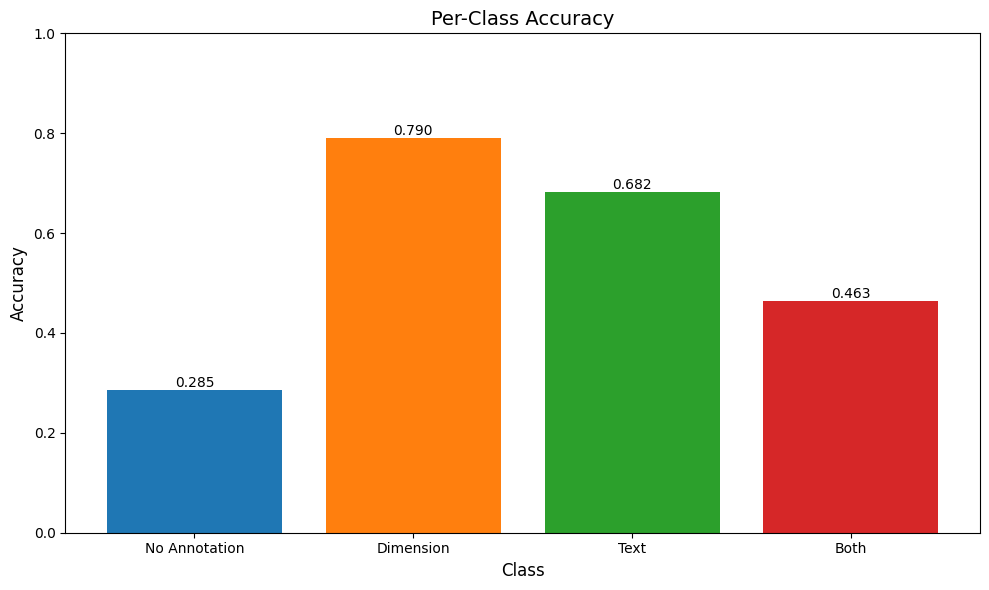


✅ All visualizations complete!
✅ Check your Google Drive: /content/output_local/


In [91]:
# Overall class accuracies histogram
print("\n📊 Generating overall class accuracies...")
plot_class_accuracies(
    all_y_true, all_y_pred, label_names,
    os.path.join(OUTPUT_DIR, "class_accuracies_overall.png")
)

print(f"\n✅ All visualizations complete!")
print(f"✅ Check your Google Drive: {OUTPUT_DIR}/")

In [92]:
# Copy results back to Google Drive
print(f"\n📤 Copying results back to Google Drive...")
if os.path.exists(LOCAL_OUTPUT):
    # Copy entire output directory to Drive
    if os.path.exists(DRIVE_OUTPUT):
        shutil.rmtree(DRIVE_OUTPUT)
    shutil.copytree(LOCAL_OUTPUT, DRIVE_OUTPUT)
    print(f"✓ Results copied to: {DRIVE_OUTPUT}")
    print(f"\n🎉 Training complete! All results saved to Google Drive.")
else:
    print(f"⚠ No local output found at {LOCAL_OUTPUT}")


📤 Copying results back to Google Drive...
✓ Results copied to: /content/drive/MyDrive/Spatial GNN/model/5.OutputML_GAT_4CLASS

🎉 Training complete! All results saved to Google Drive.
